# BioKG Dataset Exploration

Comprehensive analysis of the OGB-BioKG knowledge graph to understand its structure, connectivity patterns, and relation properties before committing to a modeling approach.

**Sections:**
1. Global statistics
2. Connected components
3. Per node-type degree analysis
4. Per relation-type analysis (density, 1-to-N classification, symmetry)
5. Target edge deep-dive (disease → protein)
6. Cross-type connectivity heatmap
7. Metapath analysis
8. Power-law analysis
9. Two-hop reachability

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Ensure project root is on path
project_root = Path(os.getcwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import load_raw_data
from src.analysis import (
    global_stats,
    connected_components,
    node_type_stats,
    degree_distributions,
    relation_type_stats,
    target_edge_analysis,
    connectivity_matrix,
    connectivity_matrix_relations,
    metapath_analysis,
    metapath_reachability,
    power_law_fit,
    power_law_summary,
    two_hop_overlap,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries loaded.")

c:\Users\wittd\anaconda3\envs\Disease-Gene-Prioritization-Project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


In [2]:
# Load the raw BioKG dataset
raw = load_raw_data("ogbl_biokg_raw.pkl")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1. Global Statistics

High-level overview: total nodes, edges, density, number of distinct node and edge types. These numbers should match the OGB-BioKG documentation (~93k nodes, ~5M edges).

In [3]:
gstats = global_stats(raw)

print(f"Total nodes:      {gstats['total_nodes']:,}")
print(f"Total edges:      {gstats['total_edges']:,}")
print(f"Graph density:    {gstats['density']:.2e}")
print(f"Node types ({gstats['num_node_types']}):  {gstats['node_types']}")
print(f"Edge types ({gstats['num_edge_types']}):")
for et in gstats["edge_types"]:
    print(f"  {et}")

Total nodes:      93,773
Total edges:      4,762,678
Graph density:    5.42e-04
Node types (5):  ['disease', 'drug', 'function', 'protein', 'sideeffect']
Edge types (51):
  disease--disease-protein--protein
  drug--drug-disease--disease
  drug--drug-drug_acquired_metabolic_disease--drug
  drug--drug-drug_bacterial_infectious_disease--drug
  drug--drug-drug_benign_neoplasm--drug
  drug--drug-drug_cancer--drug
  drug--drug-drug_cardiovascular_system_disease--drug
  drug--drug-drug_chromosomal_disease--drug
  drug--drug-drug_cognitive_disorder--drug
  drug--drug-drug_cryptorchidism--drug
  drug--drug-drug_developmental_disorder_of_mental_health--drug
  drug--drug-drug_endocrine_system_disease--drug
  drug--drug-drug_fungal_infectious_disease--drug
  drug--drug-drug_gastrointestinal_system_disease--drug
  drug--drug-drug_hematopoietic_system_disease--drug
  drug--drug-drug_hematopoietic_system_diseases--drug
  drug--drug-drug_hypospadias--drug
  drug--drug-drug_immune_system_disease--drug


## 2. Connected Components

Check if the full BioKG graph is fully connected or fragmented. A single large connected component means information can flow between all nodes via message passing.

In [ ]:
cc = connected_components(raw)

print(f"Number of connected components: {cc['num_components']}")
print(f"Largest component:  {cc['largest_component_size']:,} nodes")
print(f"Smallest component: {cc['smallest_component_size']:,} nodes")

if cc["num_components"] > 1:
    sizes = cc["component_sizes"]
    print(f"\nTop-10 component sizes: {sizes[:10]}")
    print(f"Components of size 1 (isolated nodes): {sum(1 for s in sizes if s == 1)}")
else:
    print("\nThe graph is fully connected — all nodes reachable from any node.")

# nincs izolált node de azért ezek a párok nem sokkal jobbak 
# ki kéne szűrni esetleg őket hogy csak egy nagy komponens maradjon

Number of connected components: 6
Largest component:  93,760 nodes
Smallest component: 2 nodes

Top-10 component sizes: [93760, 4, 3, 2, 2, 2]
Components of size 1 (isolated nodes): 0


## 3. Per Node-Type Statistics

For each of the 5 node types: count, degree distribution (mean, median, std, min, max, 90th/99th percentile), and number of isolated nodes. Heavy-tailed distributions are expected in biological networks.

In [5]:
ntstats = node_type_stats(raw)
ntstats

,count,isolated,mean,median,std,min,max,p90,p99
node_type,,,,,,,,,
disease,10687,0,7.3635,1.0000,32.9237,1,1841,12.0000,106.0000
drug,10533,0,241.8996,2.0000,1241.7707,1,15441,46.8000,7360.4400
function,45085,0,80.8259,33.0000,678.5295,1,62733,91.0000,752.0000
protein,17499,0,176.9940,66.0000,299.6692,1,5163,492.0000,1329.0000
sideeffect,9969,0,15.7969,5.0000,27.3690,1,263,42.0000,142.0000


### Degree Distribution Histograms

Log-scale x-axis to reveal power-law structure. Each node type gets its own subplot.

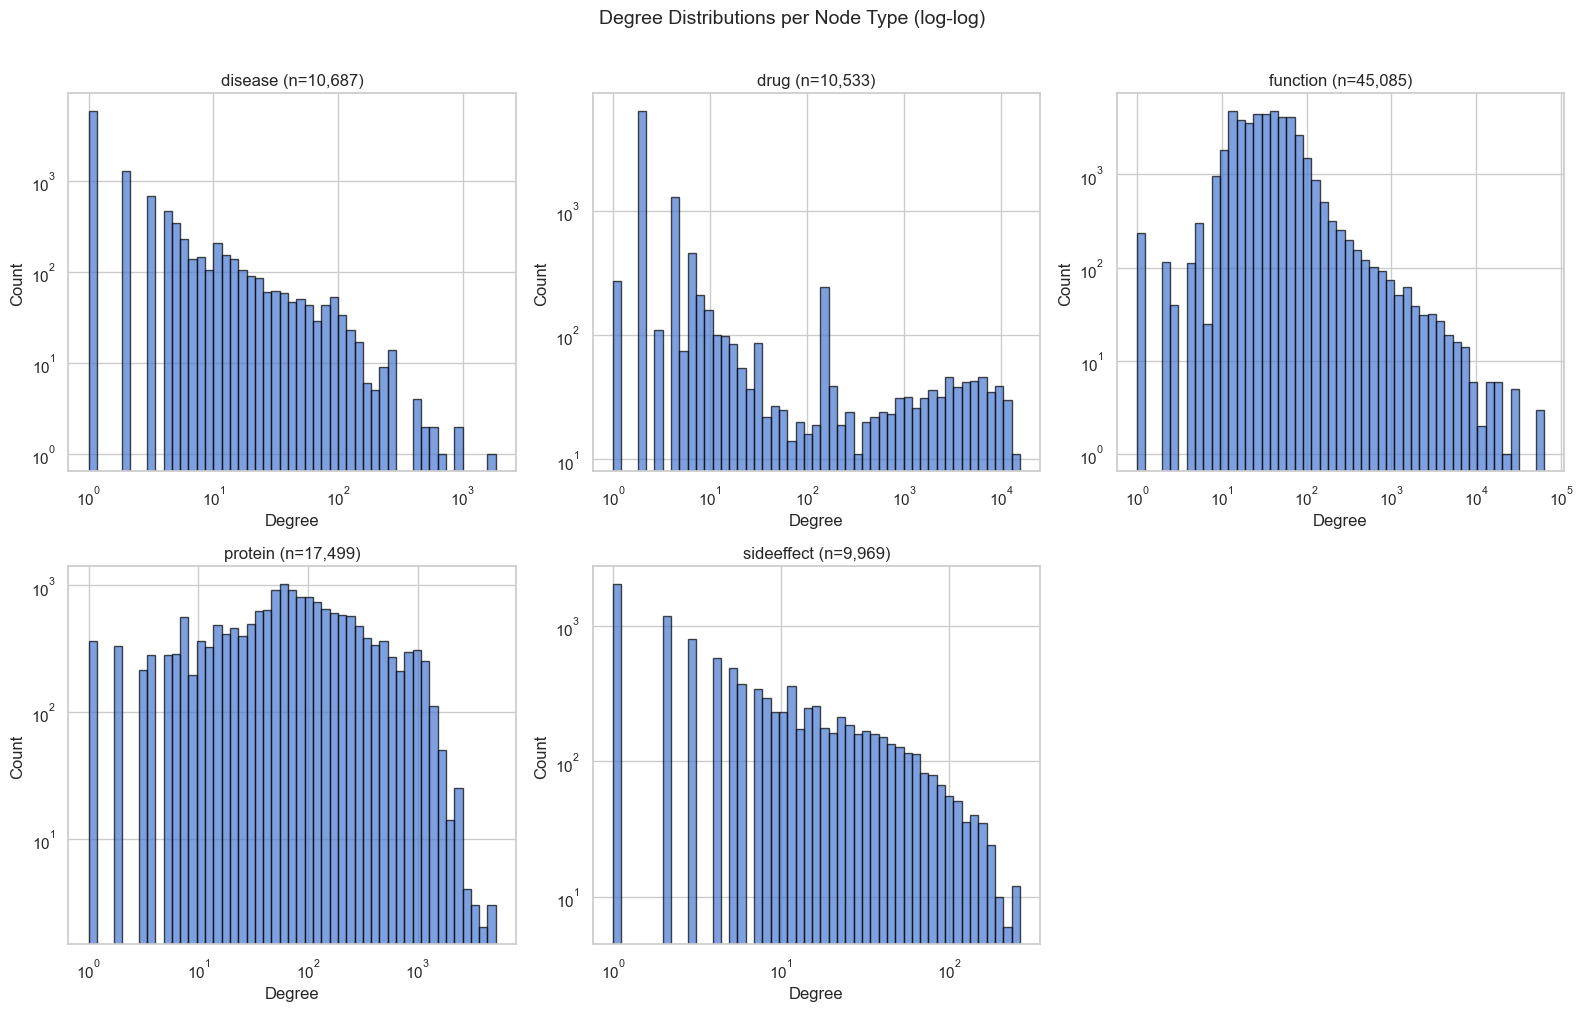

In [6]:
deg_dists = degree_distributions(raw)
node_types = sorted(deg_dists.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ntype in enumerate(node_types):
    ax = axes[i]
    degs = deg_dists[ntype]
    degs_nonzero = degs[degs > 0]
    
    if len(degs_nonzero) > 0:
        bins = np.logspace(0, np.log10(degs_nonzero.max() + 1), 50)
        ax.hist(degs_nonzero, bins=bins, edgecolor="black", alpha=0.7)
        ax.set_xscale("log")
        ax.set_yscale("log")
    
    ax.set_title(f"{ntype} (n={len(degs):,})", fontsize=12)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Count")

# Hide unused subplot
for j in range(len(node_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Degree Distributions per Node Type (log-log)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Per Relation-Type Statistics

For each of the 51 edge/relation types:
- **Edge count** and **density** (edges / possible pairs)
- **Degree stats** on both source and destination sides
- **Relation classification** (1-to-1, 1-to-N, N-to-1, N-to-N) using the RotatE heuristic: if avg tails-per-head < 1.5 → "1", else "N"
- **Symmetry ratio**: fraction of edges (h,t) where (t,h) also exists (only for same-type relations)

In [7]:
rel_stats = relation_type_stats(raw)
rel_stats

,relation,src_type,dst_type,edge_count,density,src_deg_mean,src_deg_median,src_deg_max,dst_deg_mean,dst_deg_median,dst_deg_max,avg_tails_per_head,avg_heads_per_tail,relation_class,symmetry_ratio
0,function-function,function,function,1433230,0.0007,31.7895,15.0000,26663,31.7895,15.0000,26663,32.1100,32.1100,N-to-N,1.0000
1,protein-function,protein,function,777577,0.0010,44.4355,27.0000,590,17.2469,0.0000,10215,57.4578,43.8566,N-to-N,NaN
2,protein-protein_reaction,protein,protein,352546,0.0012,20.1466,0.0000,897,20.1466,0.0000,897,67.5893,67.5893,N-to-N,1.0000
3,protein-protein_catalysis,protein,protein,303434,0.0010,17.3401,0.0000,881,17.3401,0.0000,881,56.5054,56.5054,N-to-N,1.0000
4,protein-protein_binding,protein,protein,292254,0.0010,16.7012,1.0000,756,16.7012,1.0000,756,29.4255,29.4255,N-to-N,1.0000
5,drug-sideeffect,drug,sideeffect,157479,0.0015,14.9510,0.0000,1392,15.7969,5.0000,263,246.4460,15.7969,N-to-N,NaN
6,drug-protein,drug,protein,117930,0.0006,11.1962,0.0000,3450,6.7392,0.0000,386,68.0496,15.2305,N-to-N,NaN
7,drug-drug_cardiovascular_system_disease,drug,drug,94842,0.0009,9.0043,0.0000,496,9.0043,0.0000,496,149.3575,149.3575,N-to-N,1.0000
8,drug-drug_gastrointestinal_system_disease,drug,drug,83210,0.0008,7.8999,0.0000,481,7.8999,0.0000,481,132.2893,132.2893,N-to-N,1.0000
9,drug-drug_respiratory_system_disease,drug,drug,82168,0.0007,7.8010,0.0000,475,7.8010,0.0000,475,130.0127,130.0127,N-to-N,1.0000


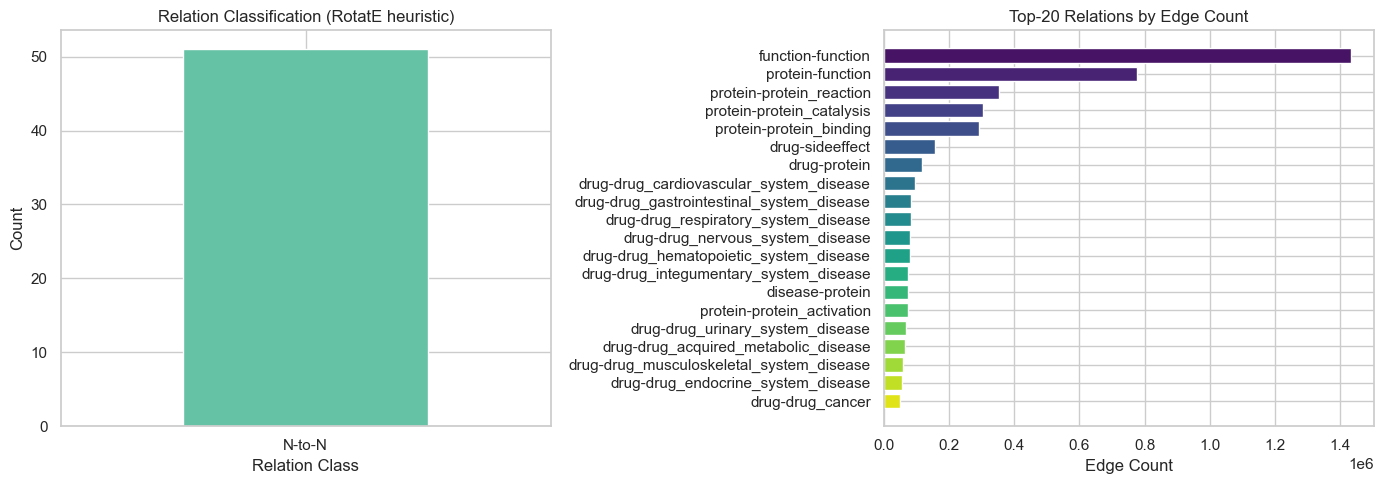

In [8]:
# Relation class distribution
rel_class_counts = rel_stats["relation_class"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of relation classes
rel_class_counts.plot.bar(ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title("Relation Classification (RotatE heuristic)")
axes[0].set_xlabel("Relation Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Edge count distribution across relations
axes[1].barh(
    rel_stats["relation"].head(20),
    rel_stats["edge_count"].head(20),
    color=sns.color_palette("viridis", 20),
)
axes[1].set_title("Top-20 Relations by Edge Count")
axes[1].set_xlabel("Edge Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# mit jelent a symmetry ratio és miért n-n minden él?

In [9]:
# Symmetry ratios for same-type relations
same_type = rel_stats[rel_stats["src_type"] == rel_stats["dst_type"]].copy()
if not same_type.empty:
    same_type = same_type.sort_values("symmetry_ratio", ascending=False)
    print("Symmetry ratios for same-type relations:")
    print(same_type[["relation", "src_type", "edge_count", "symmetry_ratio", "relation_class"]].to_string(index=False))
else:
    print("No same-type relations found.")

Symmetry ratios for same-type relations:
                                         relation src_type  edge_count  symmetry_ratio relation_class
                                function-function function     1433230          1.0000         N-to-N
                         protein-protein_reaction  protein      352546          1.0000         N-to-N
                        protein-protein_catalysis  protein      303434          1.0000         N-to-N
                          protein-protein_binding  protein      292254          1.0000         N-to-N
          drug-drug_cardiovascular_system_disease     drug       94842          1.0000         N-to-N
        drug-drug_gastrointestinal_system_disease     drug       83210          1.0000         N-to-N
             drug-drug_respiratory_system_disease     drug       82168          1.0000         N-to-N
                 drug-drug_nervous_system_disease     drug       80208          1.0000         N-to-N
           drug-drug_hematopoietic_system

## 5. Target Edge Deep-Dive: Disease → Protein

This is the prediction target. Key questions:
- How many proteins does each disease connect to? (and vice versa)
- Are there cold-start diseases with very few connections?
- Which proteins are hubs (connected to many diseases)?

In [10]:
target = target_edge_analysis(raw)

print(f"Target: {target['src_type']} → {target['dst_type']}")
print(f"Total edges: {target['total_edges']:,}")
print()
print("Disease-side degree stats (# proteins per disease):")
for k, v in target["src_degree_stats"].items():
    print(f"  {k:>8s}: {v:.2f}" if isinstance(v, float) else f"  {k:>8s}: {v}")
print()
print("Protein-side degree stats (# diseases per protein):")
for k, v in target["dst_degree_stats"].items():
    print(f"  {k:>8s}: {v:.2f}" if isinstance(v, float) else f"  {k:>8s}: {v}")
print()
print(f"Cold-start diseases (degree ≤ 2): {target['cold_start_src_lte2']}")
print(f"Isolated diseases (degree = 0):   {target['cold_start_src_zero']}")
print()
print("Top-20 hub proteins (protein_id, degree):")
for idx, deg in target["hub_dst_top20"]:
    print(f"  protein {idx:>6d}  →  {deg} diseases")

Target: disease → protein
Total edges: 73,547

Disease-side degree stats (# proteins per disease):
      mean: 6.88
    median: 1.00
       std: 32.65
       min: 0
       max: 1841
       p90: 11.00
       p99: 105.00

Protein-side degree stats (# diseases per protein):
      mean: 4.20
    median: 1.00
       std: 11.25
       min: 0
       max: 303
       p90: 11.00
       p99: 48.00

Cold-start diseases (degree ≤ 2): 7687
Isolated diseases (degree = 0):   955

Top-20 hub proteins (protein_id, degree):
  protein  13613  →  303 diseases
  protein  13185  →  260 diseases
  protein   7247  →  246 diseases
  protein   7232  →  210 diseases
  protein  10046  →  209 diseases
  protein  11570  →  209 diseases
  protein  13640  →  194 diseases
  protein   8645  →  175 diseases
  protein  11518  →  163 diseases
  protein  13933  →  160 diseases
  protein   8905  →  159 diseases
  protein   7094  →  152 diseases
  protein  15671  →  152 diseases
  protein   7051  →  151 diseases
  protein   2

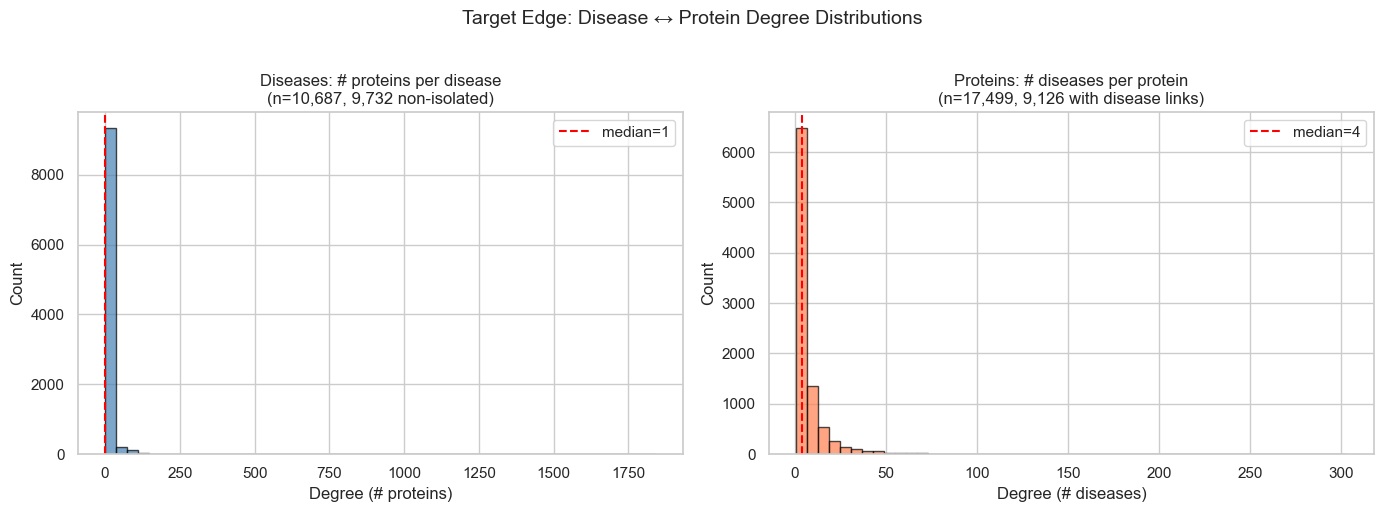

In [11]:
# Bipartite degree distributions for disease and protein sides
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Disease side
src_deg = target["src_degrees"]
src_nonzero = src_deg[src_deg > 0]
if len(src_nonzero) > 0:
    axes[0].hist(src_nonzero, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
    axes[0].set_title(f"Diseases: # proteins per disease\n(n={len(src_deg):,}, {len(src_nonzero):,} non-isolated)")
    axes[0].set_xlabel("Degree (# proteins)")
    axes[0].set_ylabel("Count")
    axes[0].axvline(np.median(src_nonzero), color="red", linestyle="--", label=f"median={np.median(src_nonzero):.0f}")
    axes[0].legend()

# Protein side
dst_deg = target["dst_degrees"]
dst_nonzero = dst_deg[dst_deg > 0]
if len(dst_nonzero) > 0:
    axes[1].hist(dst_nonzero, bins=50, edgecolor="black", alpha=0.7, color="coral")
    axes[1].set_title(f"Proteins: # diseases per protein\n(n={len(dst_deg):,}, {len(dst_nonzero):,} with disease links)")
    axes[1].set_xlabel("Degree (# diseases)")
    axes[1].set_ylabel("Count")
    axes[1].axvline(np.median(dst_nonzero), color="red", linestyle="--", label=f"median={np.median(dst_nonzero):.0f}")
    axes[1].legend()

plt.suptitle("Target Edge: Disease ↔ Protein Degree Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Cross-Type Connectivity Matrix

A heatmap showing which node types connect to which, with total edge counts. This is the schema-level view of the knowledge graph.

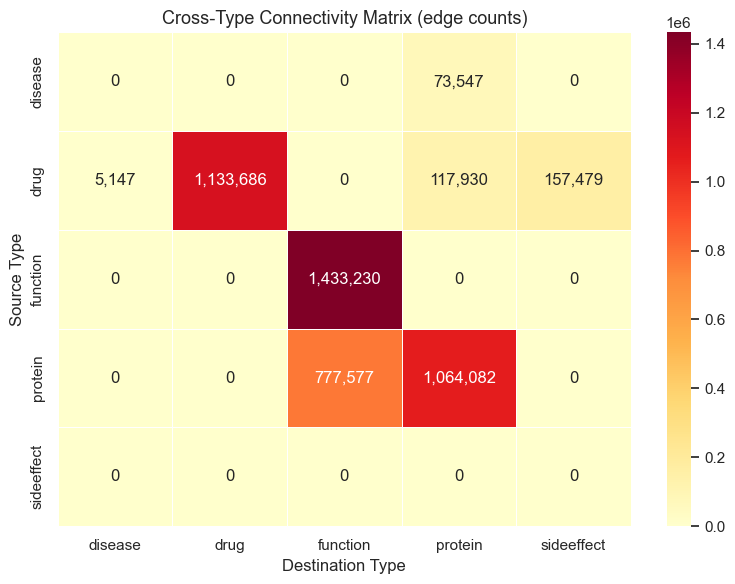

In [12]:
conn_mat = connectivity_matrix(raw)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conn_mat,
    annot=True,
    fmt=",d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Cross-Type Connectivity Matrix (edge counts)", fontsize=13)
ax.set_xlabel("Destination Type")
ax.set_ylabel("Source Type")
plt.tight_layout()
plt.show()

In [ ]:
# ez egy gráfként is megjeleníthető

In [13]:
# Detailed relation-level schema view
conn_rels = connectivity_matrix_relations(raw)
conn_rels

,src_type,relation,dst_type,count
0,disease,disease-protein,protein,73547
1,drug,drug-disease,disease,5147
2,drug,drug-drug_cardiovascular_system_disease,drug,94842
3,drug,drug-drug_gastrointestinal_system_disease,drug,83210
4,drug,drug-drug_respiratory_system_disease,drug,82168
5,drug,drug-drug_nervous_system_disease,drug,80208
6,drug,drug-drug_hematopoietic_system_disease,drug,79202
7,drug,drug-drug_integumentary_system_disease,drug,73902
8,drug,drug-drug_urinary_system_disease,drug,67326
9,drug,drug-drug_acquired_metabolic_disease,drug,63430


## 7. Metapath Analysis

Enumerate all valid metapaths from `disease` to `protein` up to 3 hops. This reveals structural patterns that multi-layer GNNs can exploit — e.g., disease→protein→protein means a 2-layer GNN can learn from protein-protein interactions to improve disease-protein prediction.

In [14]:
mp_df = metapath_analysis(raw, src_type="disease", dst_type="protein", max_length=3)
print(f"Found {len(mp_df)} distinct metapaths from disease to protein (max 3 hops):\n")
mp_df

Found 57 distinct metapaths from disease to protein (max 3 hops):



,path,length,edge_counts
0,disease--[disease-protein]--protein,1,[73547]
1,disease--[disease-protein]--protein → protein-...,2,"[73547, 73044]"
2,disease--[disease-protein]--protein → protein-...,2,"[73547, 292254]"
3,disease--[disease-protein]--protein → protein-...,2,"[73547, 303434]"
4,disease--[disease-protein]--protein → protein-...,2,"[73547, 1952]"
5,disease--[disease-protein]--protein → protein-...,2,"[73547, 352546]"
6,disease--[disease-protein]--protein → protein-...,2,"[73547, 15120]"
7,disease--[disease-protein]--protein → protein-...,2,"[73547, 25732]"
8,disease--[disease-protein]--protein → protein-...,3,"[73547, 73044, 15120]"
9,disease--[disease-protein]--protein → protein-...,3,"[73547, 73044, 352546]"


### Metapath Reachability

For selected metapaths, check what fraction of disease nodes can actually reach at least one protein via that path. This tells us which paths provide useful signal.

In [15]:
# Check reachability for length-1 and a few length-2 metapaths
# Parse the metapath tuples from the raw edge dict keys
from src.data import _raw_edge_dict

edge_keys = list(_raw_edge_dict(raw).keys())

# Build metapaths to check: all length-1 paths, and a sample of length-2
metapaths_to_check = []

# Length 1: direct disease→protein
for key in edge_keys:
    if key[0] == "disease" and key[2] == "protein":
        metapaths_to_check.append([key])

# Length 2: disease→X→protein (via any intermediate)
for k1 in edge_keys:
    if k1[0] == "disease":
        mid_type = k1[2]
        for k2 in edge_keys:
            if k2[0] == mid_type and k2[2] == "protein":
                metapaths_to_check.append([k1, k2])

print(f"Checking reachability for {len(metapaths_to_check)} metapaths...\n")

reach_results = []
for mp in metapaths_to_check:
    result = metapath_reachability(raw, mp, max_pairs=1000)
    reach_results.append(result)
    path_short = " → ".join(f"[{r}]" for _, r, _ in mp)
    print(f"  {path_short}: {result['reachable_fraction']:.1%} of diseases reach a protein  (sampled {result['sample_size']})")

Checking reachability for 8 metapaths...

  [disease-protein]: 91.9% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_activation]: 53.3% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_binding]: 75.1% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_catalysis]: 56.8% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_expression]: 33.3% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_inhibition]: 42.0% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_ptmod]: 32.5% of diseases reach a protein  (sampled 1000)
  [disease-protein] → [protein-protein_reaction]: 55.1% of diseases reach a protein  (sampled 1000)


## 8. Power-Law Analysis

Biological networks typically exhibit scale-free (power-law) degree distributions. We fit $P(k) \propto k^{-\alpha}$ via log-log OLS regression and report the exponent $\alpha$ and $R^2$.

In [16]:
pl_summary = power_law_summary(raw)
pl_summary

,exponent,r_squared
node_type,,
disease,1.2919,0.8345
drug,0.3285,0.4394
function,0.9667,0.6324
protein,1.1755,0.8426
sideeffect,1.6871,0.9316
OVERALL,1.0345,0.7546


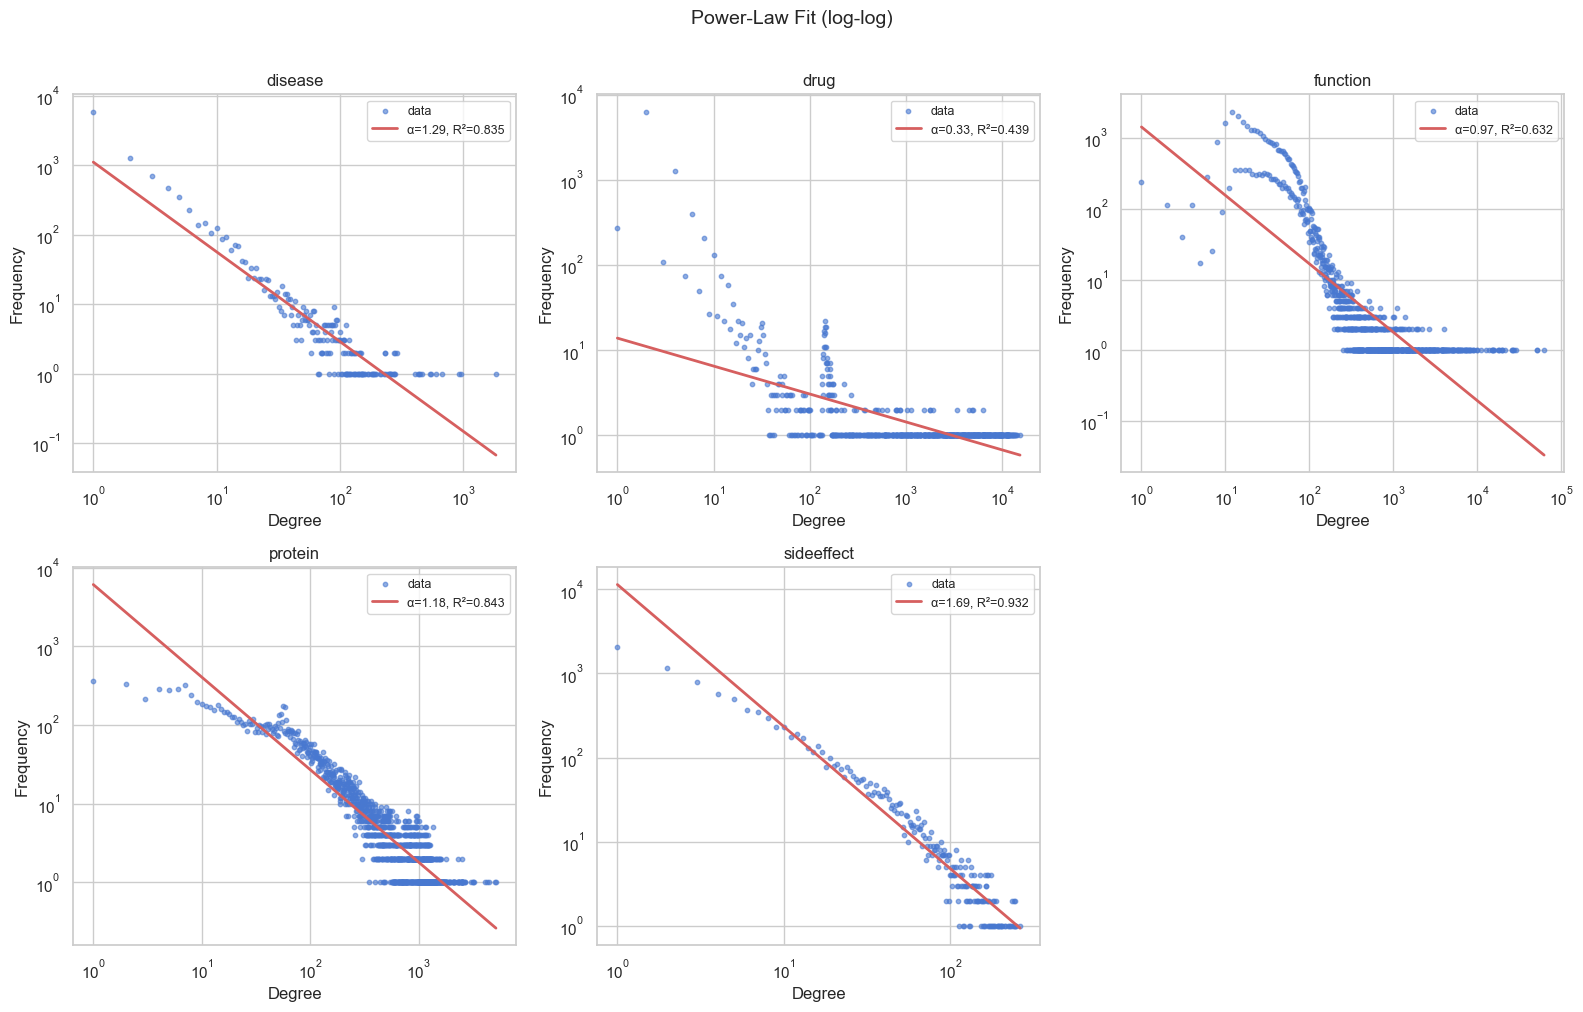

In [17]:
# Log-log plots with power-law fit lines
deg_dists = degree_distributions(raw)
node_types = sorted(deg_dists.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ntype in enumerate(node_types):
    ax = axes[i]
    degs = deg_dists[ntype]
    fit = power_law_fit(degs)

    # Scatter: log-log degree vs frequency
    degs_nonzero = degs[degs > 0]
    counts = Counter(degs_nonzero.tolist())
    deg_vals = np.array(sorted(counts.keys()))
    freq_vals = np.array([counts[d] for d in deg_vals])

    ax.scatter(deg_vals, freq_vals, s=10, alpha=0.6, label="data")

    # Fit line
    if not np.isnan(fit.get("exponent", np.nan)):
        x_fit = np.logspace(0, np.log10(deg_vals.max()), 100)
        y_fit = 10 ** (fit["fit_slope"] * np.log10(x_fit) + fit["fit_intercept"])
        ax.plot(x_fit, y_fit, "r-", linewidth=2,
                label=f"α={fit['exponent']:.2f}, R²={fit['r_squared']:.3f}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(ntype, fontsize=12)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

for j in range(len(node_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Power-Law Fit (log-log)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Two-Hop Reachability

How many additional proteins can each disease reach via protein-protein edges? A high "expansion factor" means protein-protein edges significantly increase the information neighborhood — justifying multi-hop GNN layers and the inclusion of protein-protein relations in the graph.

In [18]:
hop2 = two_hop_overlap(raw)

print("Two-hop reachability (disease → protein → protein):")
print(f"  Avg direct protein neighbors per disease:  {hop2['avg_direct_neighbors']:.1f}")
print(f"  Avg NEW proteins reachable via 2 hops:     {hop2['avg_2hop_reachable']:.1f}")
print(f"  Expansion factor:                          {hop2['expansion_factor']:.1f}x")
print(f"  Diseases sampled:                          {hop2['sample_size']}")
print(f"  Total diseases with protein edges:         {hop2['total_diseases_with_edges']}")

Two-hop reachability (disease → protein → protein):
  Avg direct protein neighbors per disease:  6.6
  Avg NEW proteins reachable via 2 hops:     247.5
  Expansion factor:                          37.3x
  Diseases sampled:                          500
  Total diseases with protein edges:         9732


## 10. Save Results

Export all computed metrics to `saves/biokg_analysis/` for reproducibility and reference in the thesis.

In [19]:
import json, yaml
from src.analysis import run_full_analysis

output_dir = Path("saves/biokg_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

# Run the full analysis suite
all_results = run_full_analysis(raw)

# Convert numpy types for JSON serialization
def make_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(x) for x in obj]
    return obj

serializable = make_serializable(all_results)

# Save as JSON
json_path = output_dir / "biokg_analysis.json"
with open(json_path, "w") as f:
    json.dump(serializable, f, indent=2)
print(f"Saved full analysis to {json_path}")

# Also save the DataFrames as CSVs
ntstats.to_csv(output_dir / "node_type_stats.csv")
rel_stats.to_csv(output_dir / "relation_type_stats.csv", index=False)
conn_mat.to_csv(output_dir / "connectivity_matrix.csv")
mp_df.to_csv(output_dir / "metapaths.csv", index=False)
pl_summary.to_csv(output_dir / "power_law_summary.csv")
print(f"Saved CSV tables to {output_dir}/")

Computing global stats...
Computing connected components...
Computing node type stats...
Computing relation type stats...
Computing target edge analysis...
Computing connectivity matrix...
Computing metapath analysis...
Computing power-law summary...
Computing two-hop overlap...
Analysis complete.
Saved full analysis to saves\biokg_analysis\biokg_analysis.json
Saved CSV tables to saves\biokg_analysis/
